# Línea de espera con dos servidores en serie

Tenemos que para una línea de espera con dos servidores en serie, donde para el primero, el usuario pasa, es atentido y de ahí para al segundo, terminado este sale del sistema. Siguiendo la notación de Kendall, tendremos que es un sistema de $M/M/2$, ya que tanto las llegadas cómo las salidas son por un proceso de Poisson.


> Usaremos numba, dado que el algoritmo dado obtenido para cada caso de una lista de espera de con dos servidores del libro de *"Simulación" de Ross*, contiene mucha condiciones y ciclos que nos alargan el tiempo de ejecución.

## Paramétros generales

In [14]:
#Librerías a usar
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from multiprocessing import Pool
import time
import os

# ============================================================
# PARÁMETROS (ajusta según necesites)
# ============================================================
lam = 1.0
mu1 = 2.0
mu2 = 3.0
maxT = 100.0
n_replicas = 500
n_lote = 20

## Caso de una línea de espera con dos servidores en serie

In [ ]:
# ============================================================
# SIMULACIÓN DE UNA RÉPLICA (TÁNDEM) CON NUMBA
# ============================================================
@njit
def simular_tandem_nb(lam, mu1, mu2, maxT):
    """
    summary: Simula una réplica de una cola en tándem 
    (dos servidores en serie) con llegadas Poisson y 
    servicios exponenciales, acelerada con Numba.
    args:
        - lam (float): Tasa de llegadas.
        - mu1 (float): Tasa de servicio del servidor 1.
        - mu2 (float): Tasa de servicio del servidor 2.
        - maxT (float): Tiempo máximo de simulación.

    returns:
        - W1_list (np.ndarray): Tiempos de cada cliente en el servidor 1 (cola + servicio).
        - W2_list (np.ndarray): Tiempos de cada cliente en el servidor 2.
        - W_list  (np.ndarray): Tiempos totales en sistema (W1 + W2).
        - Wq1_list (np.ndarray): Tiempos de espera en cola del servidor 1.
        - Wq2_list (np.ndarray): Tiempos de espera en cola del servidor 2.
        - util1 (float): Utilización real del servidor 1.
        - util2 (float): Utilización real del servidor 2.
    """
    max_possible = int(maxT * lam * 2) + 100
    arrivals = np.cumsum(np.random.exponential(1.0 / lam, max_possible))
    arrivals = arrivals[arrivals < maxT]
    n_arrivals = len(arrivals)

    q1 = np.zeros(n_arrivals + 10, dtype=np.int64)
    q2 = np.zeros(n_arrivals + 10, dtype=np.int64)
    head1 = tail1 = 0
    head2 = tail2 = 0

    A = np.zeros(n_arrivals + 10)      # llegada a serv1
    S1 = np.zeros(n_arrivals + 10)     # inicio de servicio en serv1
    A2 = np.zeros(n_arrivals + 10)     # llegada a serv2 (salida de serv1)
    S2 = np.zeros(n_arrivals + 10)     # inicio de servicio en serv2
    D = np.zeros(n_arrivals + 10)      # salida final

    idx = 0
    clock = 0.0
    n1 = n2 = 0
    client1 = 0
    client2 = 0
    t1 = 1e30
    t2 = 1e30
    arrived_count = 0
    INF = 1e30

    ocupado1 = 0.0
    ocupado2 = 0.0

    while idx < n_arrivals or n1 > 0 or n2 > 0:
        tA = arrivals[idx] if idx < n_arrivals else INF

        if tA <= t1 and tA <= t2:
            clock = tA
            arrived_count += 1
            cliente = arrived_count
            A[cliente] = clock
            q1[tail1] = cliente
            tail1 += 1
            n1 += 1

            if n1 == 1:
                client1 = q1[head1]
                head1 += 1
                S1[client1] = clock
                t1 = clock + np.random.exponential(1.0 / mu1)
                ocupado1 += t1 - clock

            idx += 1

        elif t1 <= tA and t1 <= t2:
            clock = t1
            cliente = client1
            ocupado1 += clock - S1[cliente]

            A2[cliente] = clock
            q2[tail2] = cliente
            tail2 += 1
            n2 += 1

            if n2 == 1:
                client2 = q2[head2]
                head2 += 1
                S2[client2] = clock
                t2 = clock + np.random.exponential(1.0 / mu2)
                ocupado2 += t2 - clock

            n1 -= 1
            if n1 > 0:
                client1 = q1[head1]
                head1 += 1
                S1[client1] = clock
                t1 = clock + np.random.exponential(1.0 / mu1)
                ocupado1 += t1 - clock
            else:
                t1 = INF

        else:
            clock = t2
            cliente = client2
            ocupado2 += clock - S2[cliente]
            D[cliente] = clock

            n2 -= 1
            if n2 > 0:
                client2 = q2[head2]
                head2 += 1
                S2[client2] = clock
                t2 = clock + np.random.exponential(1.0 / mu2)
                ocupado2 += t2 - clock
            else:
                t2 = INF

    # Construir arrays de tiempos (preasignados y truncados)
    max_clientes = arrived_count
    W1_arr = np.zeros(max_clientes)
    W2_arr = np.zeros(max_clientes)
    W_arr  = np.zeros(max_clientes)
    Wq1_arr = np.zeros(max_clientes)
    Wq2_arr = np.zeros(max_clientes)
    cnt = 0
    for i in range(1, arrived_count + 1):
        if D[i] > 0:
            w1 = A2[i] - A[i]
            w2 = D[i] - A2[i]
            wq1 = S1[i] - A[i]
            wq2 = S2[i] - A2[i]
            W1_arr[cnt] = w1
            W2_arr[cnt] = w2
            W_arr[cnt]  = w1 + w2
            Wq1_arr[cnt] = wq1
            Wq2_arr[cnt] = wq2
            cnt += 1

    util1 = ocupado1 / clock if clock > 0 else 0.0
    util2 = ocupado2 / clock if clock > 0 else 0.0

    return (W1_arr[:cnt], W2_arr[:cnt], W_arr[:cnt],
            Wq1_arr[:cnt], Wq2_arr[:cnt], util1, util2)

## Evolución del sistema

In [16]:

# ============================================================
# SIMULACIÓN CON HISTORIA (PARA GRÁFICA DE PASO) - OPTIMIZADA CON NUMBA
# ============================================================
@njit
def simular_tandem_historia(lam, mu1, mu2, maxT):
    """
    Simula una réplica y guarda los cambios de estado en arrays.
    Retorna: tiempos, n1, n2 (arrays de NumPy).
    """
    max_possible = int(maxT * lam * 2) + 100
    arrivals = np.cumsum(np.random.exponential(1.0 / lam, max_possible))
    arrivals = arrivals[arrivals < maxT]
    n_arrivals = len(arrivals)

    # Pre-asignar arrays para historia (máximo de eventos: llegadas + servicios)
    max_eventos = n_arrivals * 3 + 10
    t_hist = np.zeros(max_eventos)
    n1_hist = np.zeros(max_eventos, dtype=np.int64)
    n2_hist = np.zeros(max_eventos, dtype=np.int64)
    event_count = 0

    # Inicializar estado
    clock = 0.0
    n1 = n2 = 0
    cola1 = np.zeros(n_arrivals + 10, dtype=np.int64)
    cola2 = np.zeros(n_arrivals + 10, dtype=np.int64)
    head1 = tail1 = 0
    head2 = tail2 = 0
    t1 = 1e30
    t2 = 1e30
    client1 = 0
    client2 = 0
    NA = 0
    idx = 0
    INF = 1e30

    # Registrar estado inicial
    t_hist[event_count] = clock
    n1_hist[event_count] = n1
    n2_hist[event_count] = n2
    event_count += 1

    while idx < n_arrivals or n1 > 0 or n2 > 0:
        tA = arrivals[idx] if idx < n_arrivals else INF

        if tA <= t1 and tA <= t2:
            clock = tA
            NA += 1
            cola1[tail1] = NA
            tail1 += 1
            n1 += 1

            if n1 == 1:
                client1 = cola1[head1]
                head1 += 1
                t1 = clock + np.random.exponential(1.0 / mu1)

            idx += 1

        elif t1 <= tA and t1 <= t2:
            clock = t1
            n1 -= 1
            n2 += 1
            # el cliente pasa a cola2
            cola2[tail2] = client1
            tail2 += 1
            if n1 > 0:
                client1 = cola1[head1]
                head1 += 1
                t1 = clock + np.random.exponential(1.0 / mu1)
            else:
                t1 = INF

            if n2 == 1:
                client2 = cola2[head2]
                head2 += 1
                t2 = clock + np.random.exponential(1.0 / mu2)

        else:
            clock = t2
            n2 -= 1
            if n2 > 0:
                client2 = cola2[head2]
                head2 += 1
                t2 = clock + np.random.exponential(1.0 / mu2)
            else:
                t2 = INF

        # Registrar estado después del evento
        t_hist[event_count] = clock
        n1_hist[event_count] = n1
        n2_hist[event_count] = n2
        event_count += 1

    # Truncar arrays al número real de eventos
    return t_hist[:event_count], n1_hist[:event_count], n2_hist[:event_count]

## Parelelización

In [ ]:
# ============================================================
# LOTE DE RÉPLICAS PARA MULTIPROCESSING
# ============================================================
def lote_tandem(args):
    """
    summary: Ejecuta un lote de réplicas de simulación en tándem 
    y devuelve resultados agregados.

    args:
        - args (tuple): (lam, mu1, mu2, maxT, n_lote)

    returns:
        - all_W1 (list): Lista con todos los W1 del lote.
        - all_W2 (list): Lista con todos los W2.
        - all_W  (list): Lista con todos los W totales.
        - all_Wq1 (list): Lista con todos los Wq1.
        - all_Wq2 (list): Lista con todos los Wq2.
        - util1_sum/n_lote (float): Utilización promedio del servidor 1 
        en el lote.
        - util2_sum/n_lote (float): Utilización promedio del servidor 2 
        en el lote.
"""
    lam, mu1, mu2, maxT, n_lote = args
    all_W1, all_W2, all_W = [], [], []
    all_Wq1, all_Wq2 = [], []
    util1_sum = 0.0
    util2_sum = 0.0
    for _ in range(n_lote):
        W1, W2, W, Wq1, Wq2, u1, u2 = simular_tandem_nb(lam, mu1, mu2, maxT)
        all_W1.extend(W1)
        all_W2.extend(W2)
        all_W.extend(W)
        all_Wq1.extend(Wq1)
        all_Wq2.extend(Wq2)
        util1_sum += u1
        util2_sum += u2
    return (all_W1, all_W2, all_W, all_Wq1, all_Wq2,
            util1_sum/n_lote, util2_sum/n_lote)

## Ejecución y gráficas

Simulando sistema en serie (tándem) con Numba...
Tiempo de ejecución: 2.49 segundos

=== MÉTRICAS TÁNDEM ===
λ = 1.0, μ1 = 2.0, μ2 = 3.0
Utilización teórica serv1 = 0.5000, serv2 = 0.3333
Utilización real serv1     = 0.9939
Utilización real serv2     = 0.6625
--------------------------------------------------
W1 (tiempo en serv1)       = 0.9921  IC95%: [0.0242, 3.6493]
W2 (tiempo en serv2)       = 0.4989  IC95%: [0.0127, 1.8501]
W  (tiempo total)          = 1.4910  IC95%: [0.1687, 4.3493]
Wq1 (tiempo en cola serv1) = 0.4914
Wq2 (tiempo en cola serv2) = 0.1652
L1 (clientes serv1)        = 0.9921
L2 (clientes serv2)        = 0.4989
L  (clientes totales)      = 1.4910
Desv. estándar W1 = 0.9837, W2 = 0.4993, W = 1.1062


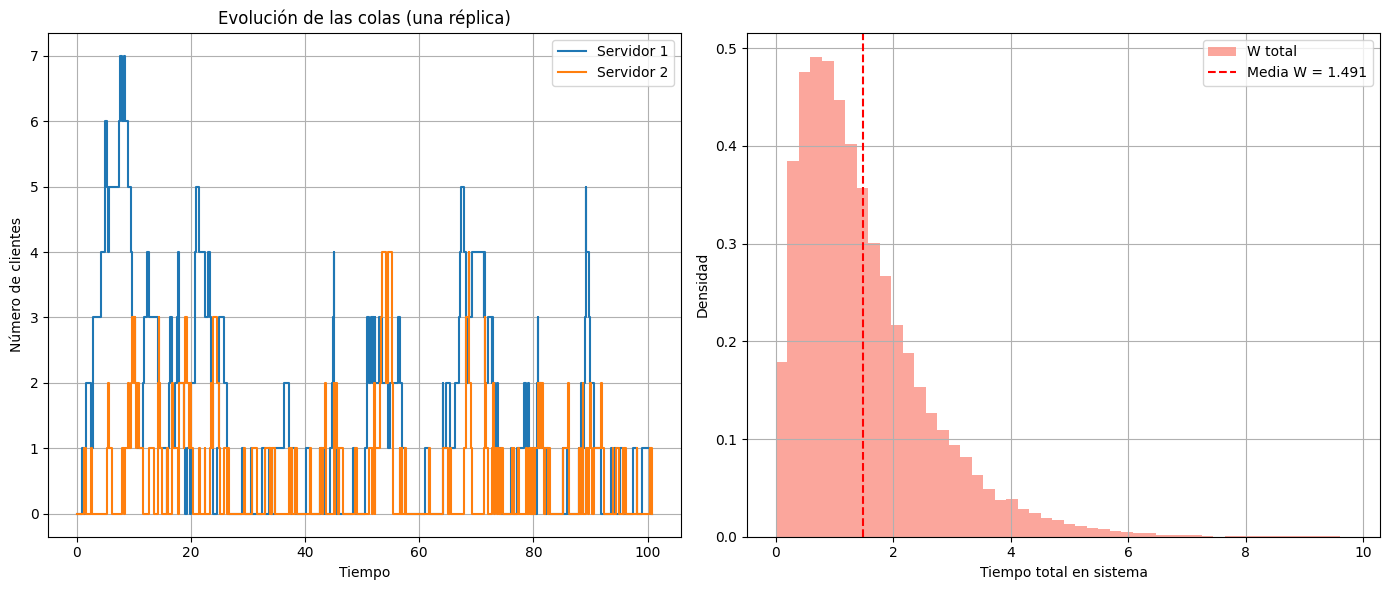

In [18]:
# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == '__main__':
    print("Simulando sistema en serie (tándem) con Numba...")
    inicio = time.time()

    n_tareas = n_replicas // n_lote
    args_list = [(lam, mu1, mu2, maxT, n_lote)] * n_tareas

    with Pool(processes=os.cpu_count()) as pool:
        resultados = pool.map(lote_tandem, args_list)

    # Unir resultados
    all_W1, all_W2, all_W = [], [], []
    all_Wq1, all_Wq2 = [], []
    util1 = util2 = 0.0
    for res in resultados:
        W1, W2, W, Wq1, Wq2, u1, u2 = res
        all_W1.extend(W1)
        all_W2.extend(W2)
        all_W.extend(W)
        all_Wq1.extend(Wq1)
        all_Wq2.extend(Wq2)
        util1 += u1
        util2 += u2
    util1 /= n_tareas
    util2 /= n_tareas

    tiempo = time.time() - inicio
    print(f"Tiempo de ejecución: {tiempo:.2f} segundos")

    # --- Métricas ---
    W1_sim = np.mean(all_W1) if all_W1 else 0
    W2_sim = np.mean(all_W2) if all_W2 else 0
    W_sim  = np.mean(all_W) if all_W else 0
    Wq1_sim = np.mean(all_Wq1) if all_Wq1 else 0
    Wq2_sim = np.mean(all_Wq2) if all_Wq2 else 0

    std_W1 = np.std(all_W1) if all_W1 else 0
    std_W2 = np.std(all_W2) if all_W2 else 0
    std_W = np.std(all_W) if all_W else 0

    throughput = lam
    L1_sim = throughput * W1_sim
    L2_sim = throughput * W2_sim
    L_sim  = throughput * W_sim

    ic_W1 = np.percentile(all_W1, [2.5, 97.5]) if all_W1 else [0, 0]
    ic_W2 = np.percentile(all_W2, [2.5, 97.5]) if all_W2 else [0, 0]
    ic_W  = np.percentile(all_W, [2.5, 97.5]) if all_W else [0, 0]

    print("\n=== MÉTRICAS TÁNDEM ===")
    print(f"λ = {lam}, μ1 = {mu1}, μ2 = {mu2}")
    print(f"Utilización teórica serv1 = {lam/mu1:.4f}, serv2 = {lam/mu2:.4f}")
    print(f"Utilización real serv1     = {util1:.4f}")
    print(f"Utilización real serv2     = {util2:.4f}")
    print("-" * 50)
    print(f"W1 (tiempo en serv1)       = {W1_sim:.4f}  IC95%: [{ic_W1[0]:.4f}, {ic_W1[1]:.4f}]")
    print(f"W2 (tiempo en serv2)       = {W2_sim:.4f}  IC95%: [{ic_W2[0]:.4f}, {ic_W2[1]:.4f}]")
    print(f"W  (tiempo total)          = {W_sim:.4f}  IC95%: [{ic_W[0]:.4f}, {ic_W[1]:.4f}]")
    print(f"Wq1 (tiempo en cola serv1) = {Wq1_sim:.4f}")
    print(f"Wq2 (tiempo en cola serv2) = {Wq2_sim:.4f}")
    print(f"L1 (clientes serv1)        = {L1_sim:.4f}")
    print(f"L2 (clientes serv2)        = {L2_sim:.4f}")
    print(f"L  (clientes totales)      = {L_sim:.4f}")
    print(f"Desv. estándar W1 = {std_W1:.4f}, W2 = {std_W2:.4f}, W = {std_W:.4f}")

    # --- Gráfica de paso (evolución temporal) con Numba ---
    t_hist, n1_hist, n2_hist = simular_tandem_historia(lam, mu1, mu2, maxT)

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.step(t_hist, n1_hist, where='post', label='Servidor 1', linewidth=1.5)
    plt.step(t_hist, n2_hist, where='post', label='Servidor 2', linewidth=1.5)
    plt.xlabel('Tiempo')
    plt.ylabel('Número de clientes')
    plt.title('Evolución de las colas (una réplica)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.hist(all_W, bins=50, density=True, alpha=0.7, color='salmon', label='W total')
    plt.axvline(W_sim, color='red', linestyle='--', label=f'Media W = {W_sim:.3f}')
    plt.xlabel('Tiempo total en sistema')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Línea de espera con dos servidores en paralelo
Tenemos que para una línea de espera con dos servidores en parelelo, donde el usuario puede ser atendido por cualquiera de los dos servidores, si el primero no esta disponible, va al segundo para ser atendido. Siguiendo la notación de Kendall tendremos que es un sitema de $M/M/2$, siendo tanto las llegadas cómo las salidads son un proceso de Poisson.

## Caso de una línea de espera con dos servidores en paralelo

In [ ]:
# ============================================================
# SIMULACIÓN DE UNA RÉPLICA (PARALELO) CON NUMBA
# ============================================================
@njit
def simular_paralelo_nb(lam, mu1, mu2, maxT):
    """
    summary: Simula una réplica de una cola con dos servidores en paralelo y cola común FIFO, acelerada con Numba.

    args:
        - lam (float): Tasa de llegadas.
        - mu1 (float): Tasa de servicio del servidor 1.
        - mu2 (float): Tasa de servicio del servidor 2.
        - maxT (float): Tiempo máximo de simulación.

    returns:
        - W_list (np.ndarray): Tiempos totales en sistema de cada cliente.
        - Wq_list (np.ndarray): Tiempos en cola de cada cliente.
        - util1 (float): Utilización real del servidor 1.
        - util2 (float): Utilización real del servidor 2.
    """
    max_possible = int(maxT * lam * 2) + 100
    arrivals = np.cumsum(np.random.exponential(1.0 / lam, max_possible))
    arrivals = arrivals[arrivals < maxT]
    n_arrivals = len(arrivals)

    cola = np.zeros(n_arrivals + 10, dtype=np.int64)
    head = tail = 0

    A = np.zeros(n_arrivals + 10)
    S = np.zeros(n_arrivals + 10)
    D = np.zeros(n_arrivals + 10)

    idx = 0
    clock = 0.0
    n = 0
    i1, i2 = 0, 0
    t1, t2 = 1e30, 1e30
    arrived_count = 0
    INF = 1e30

    ocupado1 = 0.0
    ocupado2 = 0.0

    while idx < n_arrivals or n > 0:
        tA = arrivals[idx] if idx < n_arrivals else INF

        if tA <= t1 and tA <= t2:
            clock = tA
            arrived_count += 1
            cliente = arrived_count
            A[cliente] = clock
            cola[tail] = cliente
            tail += 1
            n += 1

            if n == 1:
                i1 = cola[head]
                head += 1
                S[i1] = clock
                t1 = clock + np.random.exponential(1.0 / mu1)
                ocupado1 += t1 - clock
            elif n == 2 and i1 != 0 and i2 == 0:
                i2 = cola[head]
                head += 1
                S[i2] = clock
                t2 = clock + np.random.exponential(1.0 / mu2)
                ocupado2 += t2 - clock
            elif n == 2 and i2 != 0 and i1 == 0:
                i1 = cola[head]
                head += 1
                S[i1] = clock
                t1 = clock + np.random.exponential(1.0 / mu1)
                ocupado1 += t1 - clock
            # else: queda en cola

            idx += 1

        elif t1 <= tA and t1 <= t2:
            clock = t1
            cliente = i1
            D[cliente] = clock
            i1 = 0
            n -= 1

            if head < tail:
                i1 = cola[head]
                head += 1
                S[i1] = clock
                t1 = clock + np.random.exponential(1.0 / mu1)
                ocupado1 += t1 - clock
            else:
                t1 = INF

        else:
            clock = t2
            cliente = i2
            D[cliente] = clock
            i2 = 0
            n -= 1

            if head < tail:
                i2 = cola[head]
                head += 1
                S[i2] = clock
                t2 = clock + np.random.exponential(1.0 / mu2)
                ocupado2 += t2 - clock
            else:
                t2 = INF

    # Construir arrays de tiempos
    max_clientes = arrived_count
    W_arr = np.zeros(max_clientes)
    Wq_arr = np.zeros(max_clientes)
    cnt = 0
    for i in range(1, arrived_count + 1):
        if D[i] > 0:
            W_arr[cnt] = D[i] - A[i]
            Wq_arr[cnt] = S[i] - A[i]
            cnt += 1

    util1 = ocupado1 / clock if clock > 0 else 0.0
    util2 = ocupado2 / clock if clock > 0 else 0.0

    return W_arr[:cnt], Wq_arr[:cnt], util1, util2

## Evolución del sistema

In [20]:
# ============================================================
# SIMULACIÓN CON HISTORIA (PARALELO) - CORREGIDA CON NUMBA
# ============================================================
@njit
def simular_paralelo_historia(lam, mu1, mu2, maxT):
    """
    Retorna: tiempos, n (total clientes), ocup1 (0/1), ocup2 (0/1)
    """
    max_possible = int(maxT * lam * 2) + 100
    arrivals = np.cumsum(np.random.exponential(1.0 / lam, max_possible))
    arrivals = arrivals[arrivals < maxT]
    n_arrivals = len(arrivals)

    # Pre-asignar arrays para historia (máximo de eventos)
    max_eventos = n_arrivals * 3 + 10
    t_hist = np.zeros(max_eventos)
    n_hist = np.zeros(max_eventos, dtype=np.int64)
    ocup1_hist = np.zeros(max_eventos, dtype=np.int64)
    ocup2_hist = np.zeros(max_eventos, dtype=np.int64)
    event_count = 0

    # Inicializar estado
    clock = 0.0
    n = 0                     # total clientes en sistema
    i1 = 0                    # ID del cliente en serv1 (0 = vacío)
    i2 = 0                    # ID del cliente en serv2
    t1 = 1e30                 # próximo fin de servicio en serv1
    t2 = 1e30                 # próximo fin de servicio en serv2
    idx = 0                   # índice de llegadas

    # Cola FIFO con array y punteros
    cola = np.zeros(n_arrivals + 10, dtype=np.int64)
    head = 0
    tail = 0

    # Contador de llegadas (para asignar IDs)
    NA = 0
    INF = 1e30

    # Registrar estado inicial
    t_hist[event_count] = clock
    n_hist[event_count] = n
    ocup1_hist[event_count] = 1 if i1 != 0 else 0
    ocup2_hist[event_count] = 1 if i2 != 0 else 0
    event_count += 1

    # Bucle principal
    while idx < n_arrivals or n > 0:
        tA = arrivals[idx] if idx < n_arrivals else INF

        # ---- CASO 1: Llegada ----
        if tA <= t1 and tA <= t2:
            clock = tA
            NA += 1
            # Encolar el nuevo cliente
            cola[tail] = NA
            tail += 1
            n += 1

            # Asignar a servidor libre según el estado actual
            if n == 1:
                # Sistema vacío -> servidor 1
                i1 = cola[head]
                head += 1
                t1 = clock + np.random.exponential(1.0 / mu1)
            elif n == 2 and i1 != 0 and i2 == 0:
                # Solo serv1 ocupado -> servidor 2
                i2 = cola[head]
                head += 1
                t2 = clock + np.random.exponential(1.0 / mu2)
            elif n == 2 and i2 != 0 and i1 == 0:
                # Solo serv2 ocupado -> servidor 1
                i1 = cola[head]
                head += 1
                t1 = clock + np.random.exponential(1.0 / mu1)
            # Si n > 2, el cliente queda en cola (ya está)

            idx += 1

        # ---- CASO 2: Fin de servicio en servidor 1 ----
        elif t1 <= tA and t1 <= t2:
            clock = t1
            # El cliente que termina es i1
            i1 = 0
            n -= 1

            # Si hay clientes en cola, asignar el siguiente a serv1
            if head < tail:
                i1 = cola[head]
                head += 1
                t1 = clock + np.random.exponential(1.0 / mu1)
            else:
                t1 = INF

        # ---- CASO 3: Fin de servicio en servidor 2 ----
        else:
            clock = t2
            i2 = 0
            n -= 1

            if head < tail:
                i2 = cola[head]
                head += 1
                t2 = clock + np.random.exponential(1.0 / mu2)
            else:
                t2 = INF

        # Registrar estado después del evento
        t_hist[event_count] = clock
        n_hist[event_count] = n
        ocup1_hist[event_count] = 1 if i1 != 0 else 0
        ocup2_hist[event_count] = 1 if i2 != 0 else 0
        event_count += 1

    # Truncar arrays al número real de eventos
    return (t_hist[:event_count], n_hist[:event_count],
            ocup1_hist[:event_count], ocup2_hist[:event_count])

## Paralelización

In [ ]:
# ============================================================
# LOTE DE RÉPLICAS PARA MULTIPROCESSING
# ============================================================
def lote_paralelo(args):
    """
    summary: Ejecuta un lote de réplicas de simulación en paralelo y devuelve resultados agregados.

    args:
        - args (tuple): (lam, mu1, mu2, maxT, n_lote)

    returns:
        - all_W (list): Lista con todos los tiempos totales.
        - all_Wq (list): Lista con todos los tiempos en cola.
        - util1_sum/n_lote (float): Utilización promedio del servidor 1.
        - util2_sum/n_lot (float): Utilización promedio del servidor 2.
    """
    lam, mu1, mu2, maxT, n_lote = args
    all_W, all_Wq = [], []
    util1_sum = 0.0
    util2_sum = 0.0
    for _ in range(n_lote):
        W, Wq, u1, u2 = simular_paralelo_nb(lam, mu1, mu2, maxT)
        all_W.extend(W)
        all_Wq.extend(Wq)
        util1_sum += u1
        util2_sum += u2
    return all_W, all_Wq, util1_sum/n_lote, util2_sum/n_lote

## Ejecución y gráficas

Simulando sistema en paralelo (cola común) con Numba...


Tiempo de ejecución: 2.08 segundos

=== MÉTRICAS PARALELO ===
λ = 1.0, μ1 = 2.0, μ2 = 3.0
Utilización teórica serv1 = 0.5000, serv2 = 0.3333
Utilización real serv1     = 0.3475
Utilización real serv2     = 0.1046
--------------------------------------------------
W  (tiempo total)   = 0.4674  IC95%: [0.0120, 1.7351]
Wq (tiempo en cola) = 0.0180  IC95%: [0.0000, 0.2653]
L  (clientes totales) = 0.4674
Lq (clientes en cola) = 0.0180
Desv. estándar W  = 0.4726
Desv. estándar Wq = 0.0907


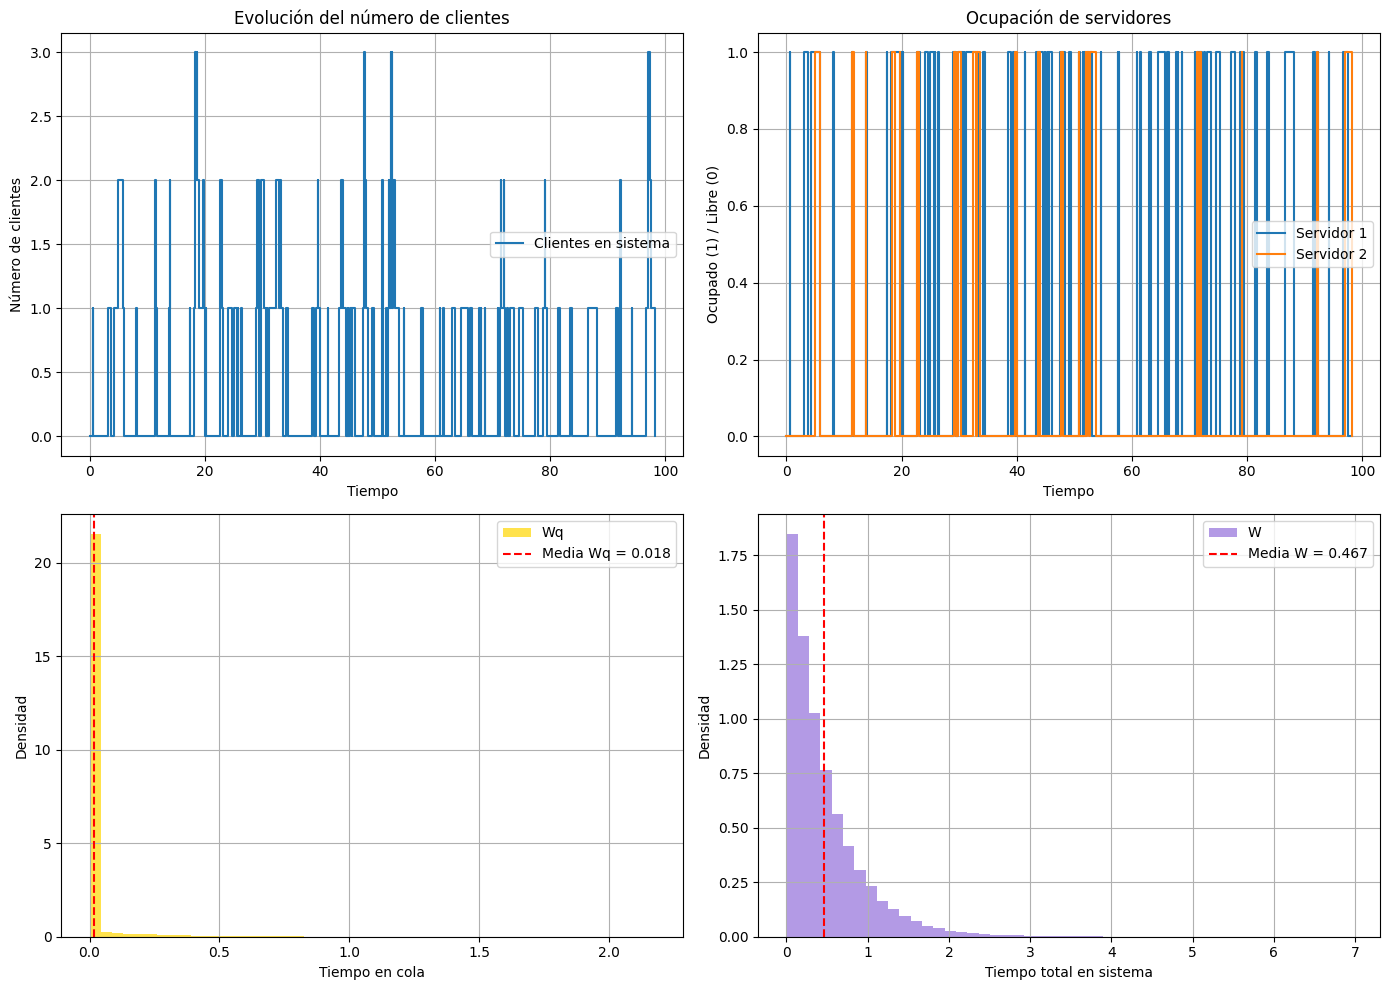

In [22]:
# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == '__main__':
    print("Simulando sistema en paralelo (cola común) con Numba...")
    inicio = time.time()

    n_tareas = n_replicas // n_lote
    args_list = [(lam, mu1, mu2, maxT, n_lote)] * n_tareas

    with Pool(processes=os.cpu_count()) as pool:
        resultados = pool.map(lote_paralelo, args_list)

    all_W, all_Wq = [], []
    util1 = util2 = 0.0
    for W, Wq, u1, u2 in resultados:
        all_W.extend(W)
        all_Wq.extend(Wq)
        util1 += u1
        util2 += u2
    util1 /= n_tareas
    util2 /= n_tareas

    tiempo = time.time() - inicio
    print(f"Tiempo de ejecución: {tiempo:.2f} segundos")

    # --- Métricas ---
    W_sim = np.mean(all_W) if all_W else 0
    Wq_sim = np.mean(all_Wq) if all_Wq else 0
    std_W = np.std(all_W) if all_W else 0
    std_Wq = np.std(all_Wq) if all_Wq else 0

    throughput = lam
    L_sim = throughput * W_sim
    Lq_sim = throughput * Wq_sim

    ic_W = np.percentile(all_W, [2.5, 97.5]) if all_W else [0, 0]
    ic_Wq = np.percentile(all_Wq, [2.5, 97.5]) if all_Wq else [0, 0]

    rho1_teo = lam / mu1 if lam < mu1 else 1.0
    rho2_teo = lam / mu2 if lam < mu2 else 1.0

    print("\n=== MÉTRICAS PARALELO ===")
    print(f"λ = {lam}, μ1 = {mu1}, μ2 = {mu2}")
    print(f"Utilización teórica serv1 = {rho1_teo:.4f}, serv2 = {rho2_teo:.4f}")
    print(f"Utilización real serv1     = {util1:.4f}")
    print(f"Utilización real serv2     = {util2:.4f}")
    print("-" * 50)
    print(f"W  (tiempo total)   = {W_sim:.4f}  IC95%: [{ic_W[0]:.4f}, {ic_W[1]:.4f}]")
    print(f"Wq (tiempo en cola) = {Wq_sim:.4f}  IC95%: [{ic_Wq[0]:.4f}, {ic_Wq[1]:.4f}]")
    print(f"L  (clientes totales) = {L_sim:.4f}")
    print(f"Lq (clientes en cola) = {Lq_sim:.4f}")
    print(f"Desv. estándar W  = {std_W:.4f}")
    print(f"Desv. estándar Wq = {std_Wq:.4f}")

    # --- Gráficas con historia optimizada ---
    t_hist, n_hist, ocup1, ocup2 = simular_paralelo_historia(lam, mu1, mu2, maxT)

    plt.figure(figsize=(14, 10))
    plt.subplot(2, 2, 1)
    plt.step(t_hist, n_hist, where='post', label='Clientes en sistema', linewidth=1.5)
    plt.xlabel('Tiempo')
    plt.ylabel('Número de clientes')
    plt.title('Evolución del número de clientes')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.step(t_hist, ocup1, where='post', label='Servidor 1', linewidth=1.5)
    plt.step(t_hist, ocup2, where='post', label='Servidor 2', linewidth=1.5)
    plt.xlabel('Tiempo')
    plt.ylabel('Ocupado (1) / Libre (0)')
    plt.title('Ocupación de servidores')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.hist(all_Wq, bins=50, density=True, alpha=0.7, color='gold', label='Wq')
    plt.axvline(Wq_sim, color='red', linestyle='--', label=f'Media Wq = {Wq_sim:.3f}')
    plt.xlabel('Tiempo en cola')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.hist(all_W, bins=50, density=True, alpha=0.7, color='mediumpurple', label='W')
    plt.axvline(W_sim, color='red', linestyle='--', label=f'Media W = {W_sim:.3f}')
    plt.xlabel('Tiempo total en sistema')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()